# ResNet-18 — Loss Function Experiment

Addresses the collapse found in notebooks 15/16 where models predicted
fraud for everything (tab0_img0 F1 = 0.000).

### Four variants compared

| Variant | Loss | pos_weight / alpha | Notes |
|---|---|---|---|
| Original | BCE | 0.56 (auto) | Too weak — collapsed to predict-all-fraud |
| Strong-3 | BCE | 3.0 | 3× penalty for missing legitimate cases |
| Strong-5 | BCE | 5.0 | 5× penalty for missing legitimate cases |
| Focal (γ=2) | Focal Loss | auto alpha | Down-weights easy examples, focuses on hard ones |

### Reference
Lin et al. (2017). Focal Loss for Dense Object Detection. ICCV 2017.

## 0 · Imports & reproducibility

In [1]:
import sys, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.metrics import roc_curve, auc as sk_auc

sys.path.insert(0, r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

from image_baseline_utils import (
    build_model, unfreeze_backbone,
    fit_model, run_test_evaluation, predict_probs,
    compute_metrics, tune_threshold,
    build_train_transform, build_val_transform,
)
from image_baseline_utils import subgroup_metrics
from mm_image_utils import (
    load_mm_splits, build_mm_dataloaders,
    make_loss_fn, subgroup_by_combo,
)
from focal_loss import BinaryFocalLoss, make_focal_loss

def set_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False

SEED   = 42
set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}  |  PyTorch {torch.__version__}")

Device : cpu  |  PyTorch 2.11.0+cpu


## 1 · Paths & config

In [2]:
PROJECT_ROOT = Path().resolve().parent
DATA_DIR     = PROJECT_ROOT / "data" / "processed"

TRAIN_CSV = DATA_DIR / "mm_train_mixed_all_group_test.csv"
VAL_CSV   = DATA_DIR / "mm_val_mixed_all_group_test.csv"
TEST_CSV  = DATA_DIR / "mm_test_mixed_all_group_test.csv"

BATCH_SIZE  = 32
NUM_WORKERS = 0
STAGE1_EPOCHS   = 5;  STAGE1_LR = 1e-3;  STAGE1_PATIENCE = 5
STAGE2_EPOCHS   = 20; BACKBONE_LR = 1e-5; HEAD_LR = 1e-4; STAGE2_PATIENCE = 6

# One results dir per variant
RESULTS_PW3   = PROJECT_ROOT / "notebook" / "results" / "mm_image_resnet18_pw3"
RESULTS_PW5   = PROJECT_ROOT / "notebook" / "results" / "mm_image_resnet18_pw5"
RESULTS_FOCAL = PROJECT_ROOT / "notebook" / "results" / "mm_image_resnet18_focal"
RESULTS_ORIG  = PROJECT_ROOT / "notebook" / "results" / "mm_image_resnet18_weighted"  # from nb 15/16

for d in [RESULTS_PW3, RESULTS_PW5, RESULTS_FOCAL]:
    d.mkdir(parents=True, exist_ok=True)

print("Results dirs ready.")

Results dirs ready.


## 2 · Load data & define loss functions

In [3]:
train_df, val_df, test_df = load_mm_splits(TRAIN_CSV, VAL_CSV, TEST_CSV)

train_loader, val_loader, test_loader = build_mm_dataloaders(
    train_df, val_df, test_df,
    train_transform=build_train_transform(),
    val_transform=build_val_transform(),
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    use_sampler=False,
)
print(f"Batches — train:{len(train_loader)} val:{len(val_loader)} test:{len(test_loader)}")

# Loss functions
print("\nLoss functions:")
print("BCE pw=3.0:")
loss_pw3   = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([3.0]).to(device))
print("BCE pw=5.0:")
loss_pw5   = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0]).to(device))
print("Focal gamma=2:")
loss_focal = make_focal_loss(train_df, device, gamma=2.0, use_alpha=True)

train: 7,182 rows | label 0:2,588 label 1:4,594 ratio 1:1.78
  combos: {'tab0_img0': 2588, 'tab0_img1': 1866, 'tab1_img0': 863, 'tab1_img1': 1865}
val: 1,508 rows | label 0:557 label 1:951 ratio 1:1.71
  combos: {'tab0_img0': 557, 'tab0_img1': 382, 'tab1_img0': 186, 'tab1_img1': 383}
test: 1,474 rows | label 0:554 label 1:920 ratio 1:1.66
  combos: {'tab0_img0': 554, 'tab0_img1': 368, 'tab1_img0': 185, 'tab1_img1': 367}
Batches — train:225 val:48 test:47

Loss functions:
BCE pw=3.0:
BCE pw=5.0:
Focal gamma=2:
  FocalLoss gamma=2.0  alpha=0.360  (n_neg=2588, n_pos=4594)


## 3 · Training & evaluation helper

In [4]:
def run_experiment(results_dir, loss_fn, variant_label):
    """Full two-stage train + eval for one loss variant."""
    print(f"\n============================================================")
    print(f"EXPERIMENT: {variant_label}")
    print(f"============================================================")

    # Stage 1
    h_s1 = None
    if (results_dir / "stage1_best.pt").exists():
        print("Stage 1 already trained — skipping.")
        model = build_model(pretrained=False, freeze_backbone=False,
                           dropout=0.3).to(device)
        model.load_state_dict(
            torch.load(results_dir / "stage1_best.pt", map_location=device))
    else:
        model = build_model(pretrained=True, freeze_backbone=True,
                           dropout=0.3).to(device)
        opt1  = torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=STAGE1_LR, weight_decay=1e-4,
        )
        model, h_s1 = fit_model(
            model=model, train_loader=train_loader, val_loader=val_loader,
            loss_fn=loss_fn, optimizer=opt1, device=device,
            epochs=STAGE1_EPOCHS, early_stopping_patience=STAGE1_PATIENCE,
            monitor_metric="val_roc_auc",
            model_save_path=results_dir / "stage1_best.pt",
        )
        display(h_s1.round(4))

    # Stage 2
    if (results_dir / "stage2_best.pt").exists():
        print("Stage 2 already trained — skipping.")
        model.load_state_dict(
            torch.load(results_dir / "stage2_best.pt", map_location=device))
    else:
        unfreeze_backbone(model)
        bp  = [p for n, p in model.named_parameters() if "fc" not in n]
        hp  = list(model.fc.parameters())
        opt2 = torch.optim.Adam(
            [{"params":bp,"lr":BACKBONE_LR},{"params":hp,"lr":HEAD_LR}],
            weight_decay=1e-4,
        )
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
        kwargs = dict(
            model=model, train_loader=train_loader, val_loader=val_loader,
            loss_fn=loss_fn, optimizer=opt2, device=device,
            epochs=STAGE2_EPOCHS, early_stopping_patience=STAGE2_PATIENCE,
            monitor_metric="val_roc_auc", scheduler=sched,
            model_save_path=results_dir / "stage2_best.pt",
        )
        pass  # ResNet: no freeze_bn needed
        model, h_s2 = fit_model(**kwargs)
        hist = pd.concat([h_s1, h_s2], ignore_index=True) if h_s1 is not None else h_s2.copy()
        hist["epoch"] = range(1, len(hist)+1)
        hist.to_csv(results_dir / "training_history.csv", index=False)
        display(h_s2.round(4))

    model.eval()

    # Evaluate
    val_y, val_p = predict_probs(model, val_loader, device)
    thresh, _    = tune_threshold(val_y, val_p, metric="f1")

    test_metrics = run_test_evaluation(
        model=model, test_loader=test_loader,
        loss_fn=loss_fn, device=device, threshold=thresh,
    )
    y_true, y_prob = predict_probs(model, test_loader, device)
    pred_df = test_df.reset_index(drop=True).copy()
    pred_df["y_true"] = y_true
    pred_df["y_prob"] = y_prob
    pred_df["y_pred"] = (pred_df["y_prob"] >= thresh).astype(int)
    pred_df.to_csv(results_dir / "test_predictions.csv", index=False)

    sg = subgroup_by_combo(pred_df, thresh)
    sg.to_csv(results_dir / "subgroup_combo_type.csv", index=False)

    print(f"\n  tab0_img0 F1 = {sg[sg['combo_type']=='tab0_img0']['f1'].values[0]:.3f}")
    print(f"  tab1_img0 F1 = {sg[sg['combo_type']=='tab1_img0']['f1'].values[0]:.3f}")

    return {"label":variant_label, "threshold":thresh, "metrics":test_metrics,
             "pred_df":pred_df, "sg":sg, "y_true":y_true, "y_prob":y_prob}

---
## 4 · Run experiments

In [5]:
res_pw3   = run_experiment(RESULTS_PW3,   loss_pw3,   "BCE  pw=3.0")
res_pw5   = run_experiment(RESULTS_PW5,   loss_pw5,   "BCE  pw=5.0")
res_focal = run_experiment(RESULTS_FOCAL, loss_focal, "Focal γ=2.0")


EXPERIMENT: BCE  pw=3.0
Epoch 01 | lr=1.00e-03 | train_loss=0.8616 | val_loss=0.7690 | val_f1=0.8012 | val_roc_auc=0.8339
  ✓ Saved best model (epoch 1, val_roc_auc=0.8339)
Epoch 02 | lr=1.00e-03 | train_loss=0.7846 | val_loss=0.7493 | val_f1=0.8122 | val_roc_auc=0.8463
  ✓ Saved best model (epoch 2, val_roc_auc=0.8463)
Epoch 03 | lr=1.00e-03 | train_loss=0.7736 | val_loss=0.7368 | val_f1=0.8124 | val_roc_auc=0.8532
  ✓ Saved best model (epoch 3, val_roc_auc=0.8532)
Epoch 04 | lr=1.00e-03 | train_loss=0.7515 | val_loss=0.7555 | val_f1=0.8379 | val_roc_auc=0.8583
  ✓ Saved best model (epoch 4, val_roc_auc=0.8583)
Epoch 05 | lr=1.00e-03 | train_loss=0.7660 | val_loss=0.7306 | val_f1=0.8212 | val_roc_auc=0.8603
  ✓ Saved best model (epoch 5, val_roc_auc=0.8603)
Restored best weights (val_roc_auc=0.8603).


,epoch,lr,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.001,0.8616,0.7690,0.6996,0.6875,0.9600,0.8012,0.8339
1,2,0.001,0.7846,0.7493,0.7294,0.7224,0.9274,0.8122,0.8463
2,3,0.001,0.7736,0.7368,0.7261,0.7152,0.9401,0.8124,0.8532
3,4,0.001,0.7515,0.7555,0.7818,0.7885,0.8938,0.8379,0.8583
4,5,0.001,0.7660,0.7306,0.7500,0.7478,0.9106,0.8212,0.8603


Backbone unfrozen — all parameters now trainable.
Epoch 01 | lr=1.00e-05 | train_loss=0.7315 | val_loss=0.6943 | val_f1=0.8085 | val_roc_auc=0.8710
  ✓ Saved best model (epoch 1, val_roc_auc=0.8710)
Epoch 02 | lr=9.94e-06 | train_loss=0.6979 | val_loss=0.6804 | val_f1=0.8159 | val_roc_auc=0.8732
  ✓ Saved best model (epoch 2, val_roc_auc=0.8732)
Epoch 03 | lr=9.76e-06 | train_loss=0.6803 | val_loss=0.6759 | val_f1=0.8244 | val_roc_auc=0.8736
  ✓ Saved best model (epoch 3, val_roc_auc=0.8736)
Epoch 04 | lr=9.46e-06 | train_loss=0.6687 | val_loss=0.6734 | val_f1=0.8194 | val_roc_auc=0.8734
Epoch 05 | lr=9.05e-06 | train_loss=0.6621 | val_loss=0.6705 | val_f1=0.8179 | val_roc_auc=0.8733
Epoch 06 | lr=8.55e-06 | train_loss=0.6567 | val_loss=0.6851 | val_f1=0.8226 | val_roc_auc=0.8713
Epoch 07 | lr=7.96e-06 | train_loss=0.6450 | val_loss=0.6697 | val_f1=0.8065 | val_roc_auc=0.8730
Epoch 08 | lr=7.30e-06 | train_loss=0.6451 | val_loss=0.6699 | val_f1=0.8099 | val_roc_auc=0.8722
Epoch 09 | lr

,epoch,lr,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.0,0.7315,0.6943,0.7235,0.7178,0.9253,0.8085,0.8710
1,2,0.0,0.6979,0.6804,0.7394,0.7356,0.9159,0.8159,0.8732
2,3,0.0,0.6803,0.6759,0.7580,0.7598,0.9012,0.8244,0.8736
3,4,0.0,0.6687,0.6734,0.7480,0.7476,0.9064,0.8194,0.8734
4,5,0.0,0.6621,0.6705,0.7460,0.7465,0.9043,0.8179,0.8733
5,6,0.0,0.6567,0.6851,0.7580,0.7649,0.8896,0.8226,0.8713
6,7,0.0,0.6450,0.6697,0.7228,0.7204,0.9159,0.8065,0.8730
7,8,0.0,0.6451,0.6699,0.7308,0.7300,0.9096,0.8099,0.8722
8,9,0.0,0.6404,0.6720,0.7467,0.7533,0.8896,0.8158,0.8695



Best threshold (f1): 0.70

── TEST METRICS ──────────────────────────────
  loss        : 0.6670
  accuracy    : 0.8304
  precision   : 0.8868
  recall      : 0.8348
  f1          : 0.8600
  roc_auc     : 0.8786
  confusion_matrix:
[[456  98]
 [152 768]]
──────────────────────────────────────────────

  tab0_img0 F1 = 0.000
  tab1_img0 F1 = 0.318

EXPERIMENT: BCE  pw=5.0
Epoch 01 | lr=1.00e-03 | train_loss=1.0788 | val_loss=0.9307 | val_f1=0.7745 | val_roc_auc=0.8324
  ✓ Saved best model (epoch 1, val_roc_auc=0.8324)
Epoch 02 | lr=1.00e-03 | train_loss=0.9634 | val_loss=0.9021 | val_f1=0.7760 | val_roc_auc=0.8486
  ✓ Saved best model (epoch 2, val_roc_auc=0.8486)
Epoch 03 | lr=1.00e-03 | train_loss=0.9387 | val_loss=0.9154 | val_f1=0.7734 | val_roc_auc=0.8521
  ✓ Saved best model (epoch 3, val_roc_auc=0.8521)
Epoch 04 | lr=1.00e-03 | train_loss=0.9206 | val_loss=0.8870 | val_f1=0.7776 | val_roc_auc=0.8577
  ✓ Saved best model (epoch 4, val_roc_auc=0.8577)
Epoch 05 | lr=1.00e-03 | trai

...


Best threshold (f1): 0.80

── TEST METRICS ──────────────────────────────
  loss        : 0.8100
  accuracy    : 0.8290
  precision   : 0.8770
  recall      : 0.8446
  f1          : 0.8605
  roc_auc     : 0.8823
  confusion_matrix:
[[445 109]
 [143 777]]
──────────────────────────────────────────────

  tab0_img0 F1 = 0.000
  tab1_img0 F1 = 0.370

EXPERIMENT: Focal γ=2.0
Epoch 01 | lr=1.00e-03 | train_loss=0.0740 | val_loss=0.0570 | val_f1=0.8015 | val_roc_auc=0.8522
  ✓ Saved best model (epoch 1, val_roc_auc=0.8522)
Epoch 02 | lr=1.00e-03 | train_loss=0.0628 | val_loss=0.0563 | val_f1=0.7638 | val_roc_auc=0.8605
  ✓ Saved best model (epoch 2, val_roc_auc=0.8605)
Epoch 03 | lr=1.00e-03 | train_loss=0.0619 | val_loss=0.0550 | val_f1=0.7831 | val_roc_auc=0.8656
  ✓ Saved best model (epoch 3, val_roc_auc=0.8656)
Epoch 04 | lr=1.00e-03 | train_loss=0.0608 | val_loss=0.0572 | val_f1=0.8466 | val_roc_auc=0.8701
  ✓ Saved best model (epoch 4, val_roc_auc=0.8701)
Epoch 05 | lr=1.00e-03 | trai

,epoch,lr,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.001,0.0740,0.0570,0.7613,0.8424,0.7645,0.8015,0.8522
1,2,0.001,0.0628,0.0563,0.7454,0.9200,0.6530,0.7638,0.8605
2,3,0.001,0.0619,0.0550,0.7619,0.9205,0.6814,0.7831,0.8656
3,4,0.001,0.0608,0.0572,0.8017,0.8267,0.8675,0.8466,0.8701
4,5,0.001,0.0604,0.0532,0.8064,0.8682,0.8170,0.8418,0.8676


Backbone unfrozen — all parameters now trainable.
Epoch 01 | lr=1.00e-05 | train_loss=0.0552 | val_loss=0.0503 | val_f1=0.8243 | val_roc_auc=0.8754
  ✓ Saved best model (epoch 1, val_roc_auc=0.8754)
Epoch 02 | lr=9.94e-06 | train_loss=0.0537 | val_loss=0.0488 | val_f1=0.8407 | val_roc_auc=0.8789
  ✓ Saved best model (epoch 2, val_roc_auc=0.8789)
Epoch 03 | lr=9.76e-06 | train_loss=0.0513 | val_loss=0.0487 | val_f1=0.8232 | val_roc_auc=0.8806
  ✓ Saved best model (epoch 3, val_roc_auc=0.8806)
Epoch 04 | lr=9.46e-06 | train_loss=0.0508 | val_loss=0.0489 | val_f1=0.8178 | val_roc_auc=0.8806
Epoch 05 | lr=9.05e-06 | train_loss=0.0491 | val_loss=0.0480 | val_f1=0.8429 | val_roc_auc=0.8791
Epoch 06 | lr=8.55e-06 | train_loss=0.0486 | val_loss=0.0478 | val_f1=0.8517 | val_roc_auc=0.8791
Epoch 07 | lr=7.96e-06 | train_loss=0.0472 | val_loss=0.0483 | val_f1=0.8313 | val_roc_auc=0.8798
Epoch 08 | lr=7.30e-06 | train_loss=0.0471 | val_loss=0.0479 | val_f1=0.8445 | val_roc_auc=0.8776
Epoch 09 | lr

,epoch,lr,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.0,0.0552,0.0503,0.7971,0.9077,0.7550,0.8243,0.8754
1,2,0.0,0.0537,0.0488,0.8123,0.9044,0.7855,0.8407,0.8789
2,3,0.0,0.0513,0.0487,0.7977,0.9173,0.7466,0.8232,0.8806
3,4,0.0,0.0508,0.0489,0.7931,0.9198,0.7361,0.8178,0.8806
4,5,0.0,0.0491,0.0480,0.8163,0.9150,0.7813,0.8429,0.8791
5,6,0.0,0.0486,0.0478,0.8236,0.9063,0.8034,0.8517,0.8791
6,7,0.0,0.0472,0.0483,0.8057,0.9186,0.7592,0.8313,0.8798
7,8,0.0,0.0471,0.0479,0.8176,0.9132,0.7855,0.8445,0.8776
8,9,0.0,0.0473,0.0480,0.8117,0.9143,0.7739,0.8383,0.8778



Best threshold (f1): 0.40

── TEST METRICS ──────────────────────────────
  loss        : 0.0484
  accuracy    : 0.8256
  precision   : 0.8721
  recall      : 0.8446
  f1          : 0.8581
  roc_auc     : 0.8809
  confusion_matrix:
[[440 114]
 [143 777]]
──────────────────────────────────────────────

  tab0_img0 F1 = 0.000
  tab1_img0 F1 = 0.370


## 5 · Load original results (from notebook 15/16)

In [6]:
orig_path = RESULTS_ORIG / "test_predictions.csv"

if orig_path.exists():
    orig_pred = pd.read_csv(orig_path)
    orig_sweep = pd.read_csv(RESULTS_ORIG / "threshold_sweep.csv")
    orig_thresh = float(orig_sweep.loc[orig_sweep["f1"].idxmax(), "threshold"])
    from image_baseline_utils import compute_metrics
    orig_metrics = compute_metrics(orig_pred["y_true"].values,
                                   orig_pred["y_prob"].values, orig_thresh)
    sg_orig = subgroup_by_combo(orig_pred, orig_thresh)
    results = [
        {"label":"Original (pw=0.56)", "threshold":orig_thresh,
          "metrics":orig_metrics, "pred_df":orig_pred,
          "sg":sg_orig, "y_true":orig_pred["y_true"].values,
          "y_prob":orig_pred["y_prob"].values},
        res_pw3, res_pw5, res_focal,
    ]
    print("All four variants loaded.")
else:
    print("Original results not found — run notebook 15 first.")
    results = [res_pw3, res_pw5, res_focal]

All four variants loaded.


---
## 6 · Overall metrics comparison

,variant,threshold,accuracy,precision,recall,f1,roc_auc
0,Original (pw=0.56),0.35,0.8331,0.8955,0.8293,0.8612,0.8821
1,BCE pw=3.0,0.70,0.8304,0.8868,0.8348,0.8600,0.8786
2,BCE pw=5.0,0.80,0.8290,0.8770,0.8446,0.8605,0.8823
3,Focal γ=2.0,0.40,0.8256,0.8721,0.8446,0.8581,0.8809


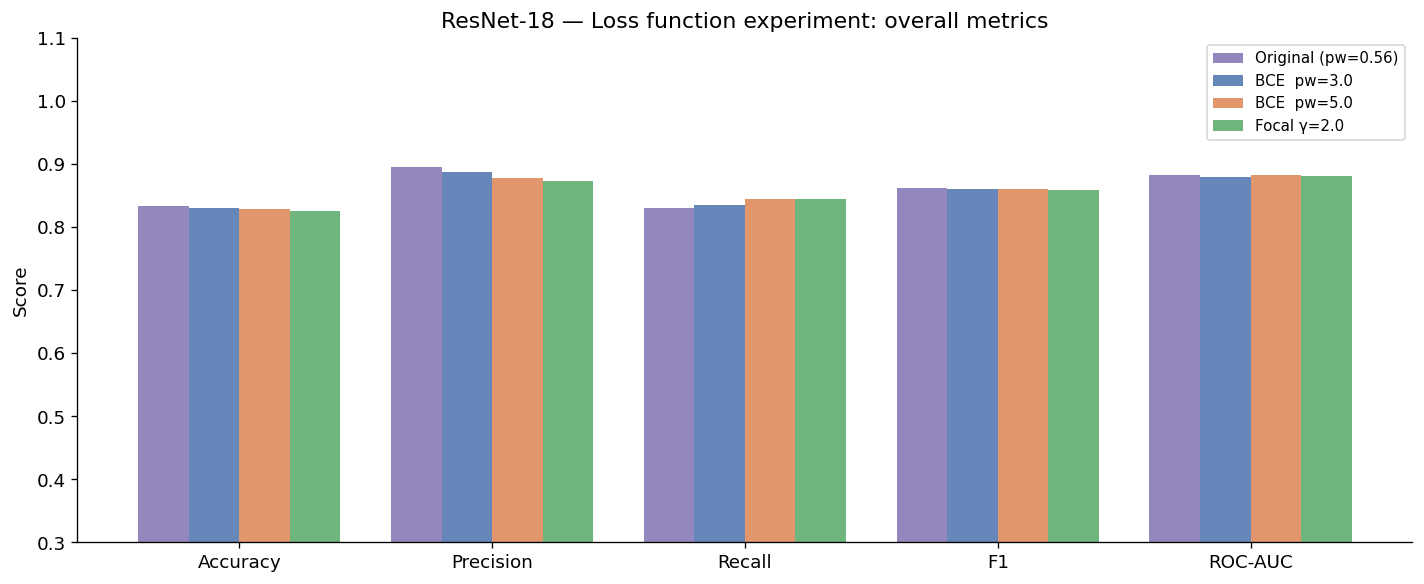

In [7]:
rows = []
for r in results:
    m = r["metrics"]
    rows.append({"variant":r["label"], "threshold":r["threshold"],
                  "accuracy":m["accuracy"], "precision":m["precision"],
                  "recall":m["recall"], "f1":m["f1"], "roc_auc":m["roc_auc"]})

cmp_df = pd.DataFrame(rows)
display(cmp_df.round(4))
cmp_df.to_csv(RESULTS_PW3.parent / "mm_image_resnet18_loss_experiment_comparison.csv", index=False)

metrics_plot = ["accuracy","precision","recall","f1","roc_auc"]
x = np.arange(len(metrics_plot)); width = 0.2
colours = ["#8172B2","#4C72B0","#DD8452","#55A868"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (_, row) in enumerate(cmp_df.iterrows()):
    ax.bar(x + i*width, [row[m] for m in metrics_plot],
           width, label=row["variant"], color=colours[i%len(colours)], alpha=0.85)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(["Accuracy","Precision","Recall","F1","ROC-AUC"])
ax.set_ylim(0.3, 1.1); ax.set_ylabel("Score")
ax.set_title("ResNet-18 — Loss function experiment: overall metrics")
ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_PW3.parent / "mm_image_resnet18_loss_exp_overall.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 7 · Subgroup comparison by combo_type
**The key diagnostic.** Does any variant fix `tab0_img0 F1 = 0.000`?

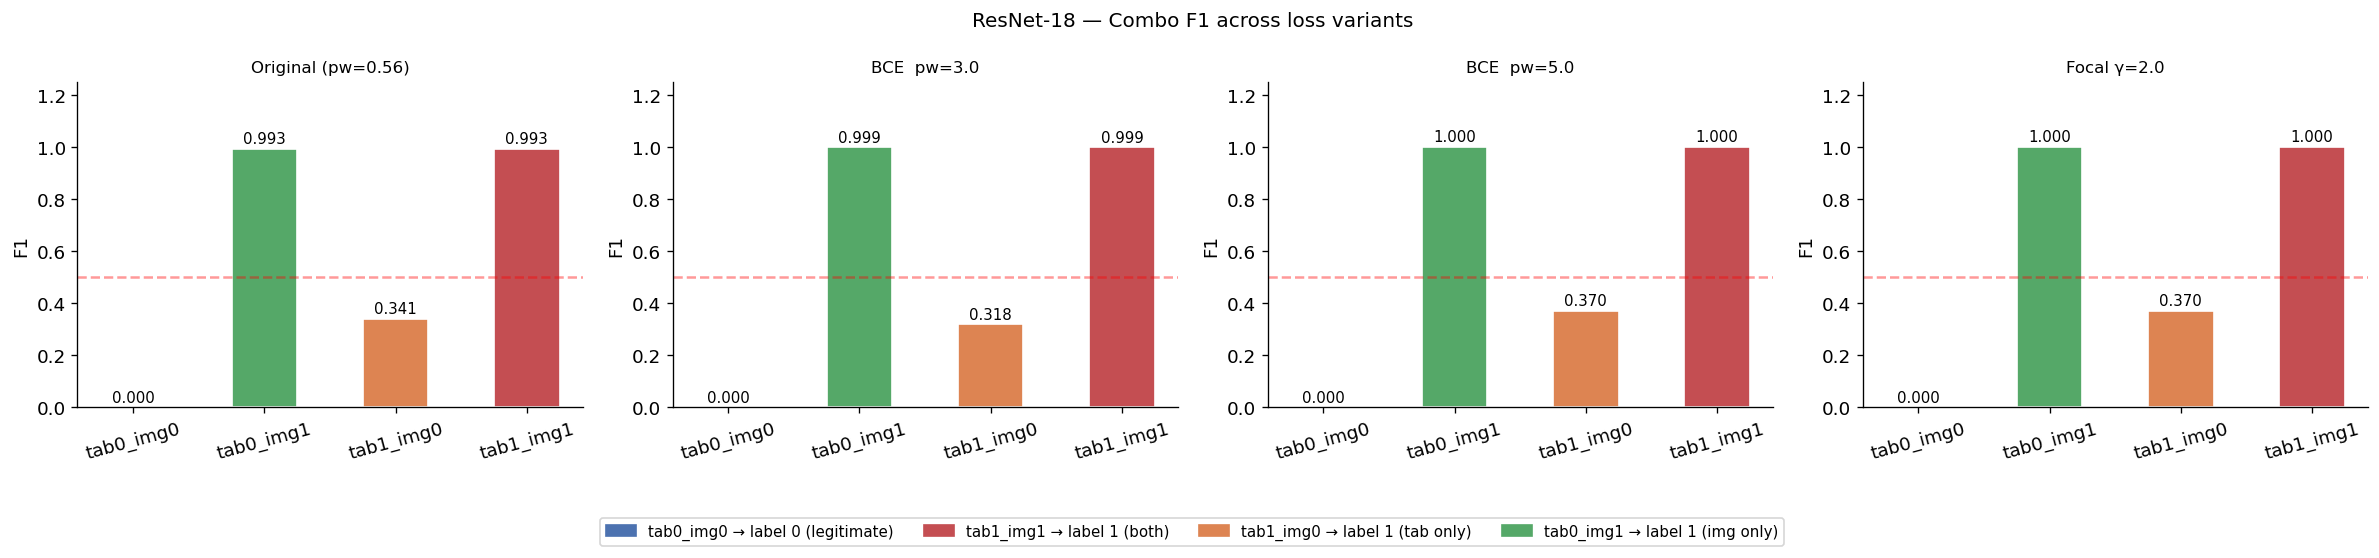

In [8]:
COMBO_COLOURS = {"tab0_img0":"#4C72B0","tab1_img1":"#C44E52",
                 "tab1_img0":"#DD8452","tab0_img1":"#55A868"}

fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 4))
if len(results) == 1: axes = [axes]

for ax, r in zip(axes, results):
    sg = r["sg"]
    colours = [COMBO_COLOURS.get(c,"gray") for c in sg["combo_type"]]
    bars = ax.bar(sg["combo_type"], sg["f1"],
                  color=colours, edgecolor="white", width=0.5)
    for bar, val in zip(bars, sg["f1"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, 1.25); ax.set_title(r["label"], fontsize=10)
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.4)
    ax.set_ylabel("F1"); ax.tick_params(axis="x", rotation=15)
    ax.spines[["top","right"]].set_visible(False)

fig.legend(handles=[
    Patch(color="#4C72B0",label="tab0_img0 → label 0 (legitimate)"),
    Patch(color="#C44E52",label="tab1_img1 → label 1 (both)"),
    Patch(color="#DD8452",label="tab1_img0 → label 1 (tab only)"),
    Patch(color="#55A868",label="tab0_img1 → label 1 (img only)"),
], loc="lower center", ncol=4, bbox_to_anchor=(0.5,-0.15), fontsize=9)
fig.suptitle("ResNet-18 — Combo F1 across loss variants", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_PW3.parent / "mm_image_resnet18_loss_exp_combo.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 8 · ROC curves

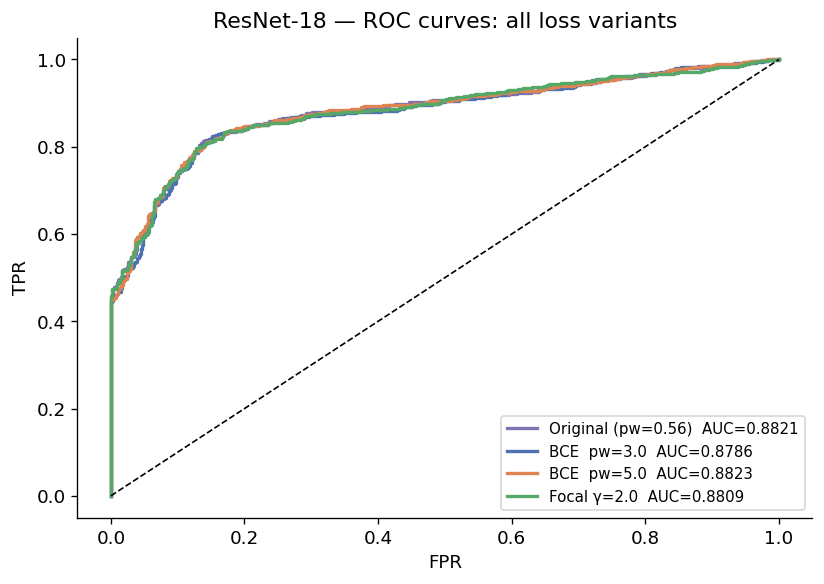

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
colours_roc = ["#8172B2","#4C72B0","#DD8452","#55A868"]

for i, r in enumerate(results):
    fpr, tpr, _ = roc_curve(r["y_true"], r["y_prob"])
    ax.plot(fpr, tpr, color=colours_roc[i%len(colours_roc)], lw=2,
            label=f"{r['label']}  AUC={sk_auc(fpr,tpr):.4f}")

ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ResNet-18 — ROC curves: all loss variants")
ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_PW3.parent / "mm_image_resnet18_loss_exp_roc.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 9 · Score distributions

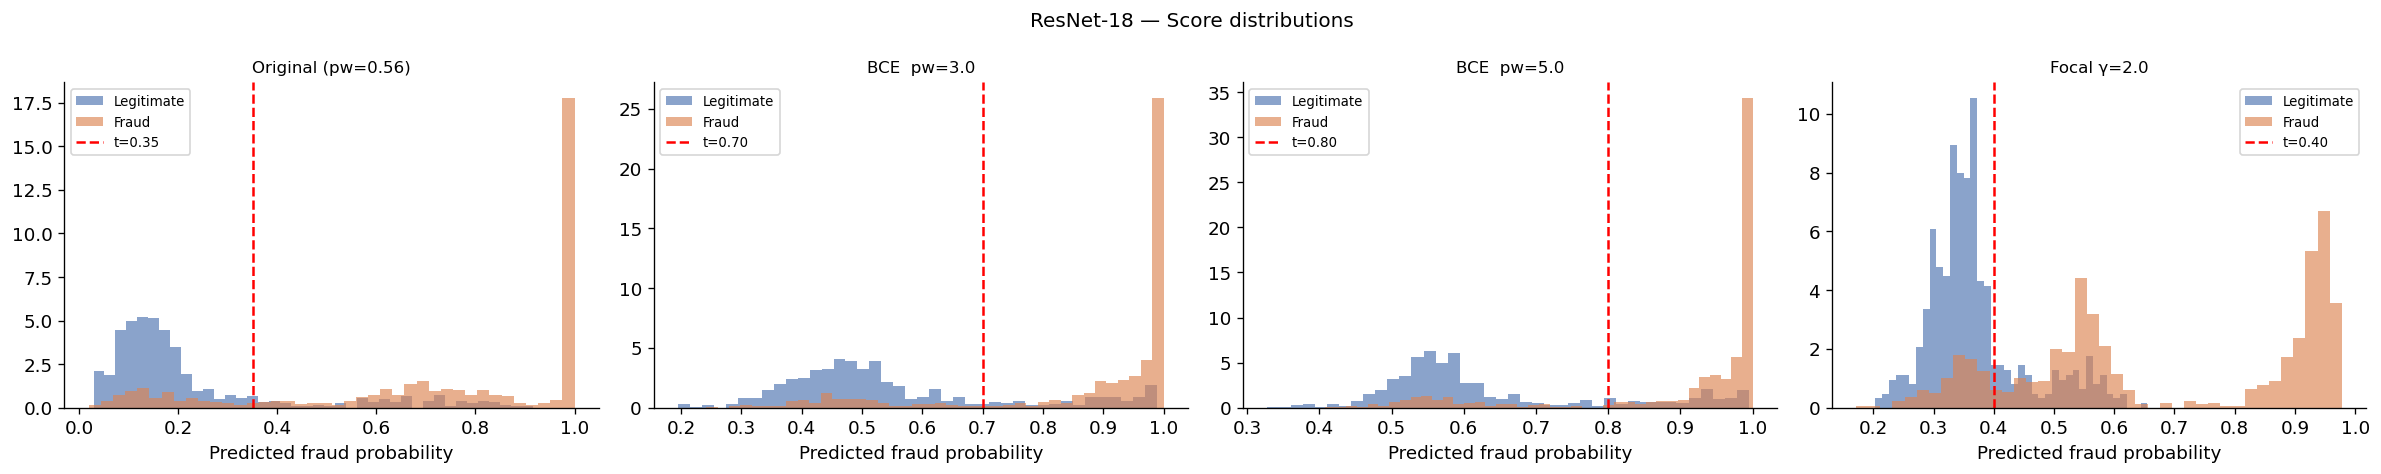

In [10]:
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1: axes = [axes]

for ax, r in zip(axes, results):
    ax.hist(r["y_prob"][r["y_true"]==0], bins=40, alpha=0.65,
            color="#4C72B0", label="Legitimate", density=True)
    ax.hist(r["y_prob"][r["y_true"]==1], bins=40, alpha=0.65,
            color="#DD8452", label="Fraud",      density=True)
    ax.axvline(x=r["threshold"], color="red", linestyle="--",
               label=f"t={r['threshold']:.2f}")
    ax.set_title(r["label"], fontsize=10)
    ax.set_xlabel("Predicted fraud probability")
    ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)

fig.suptitle("ResNet-18 — Score distributions", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_PW3.parent / "mm_image_resnet18_loss_exp_scores.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 10 · Summary table

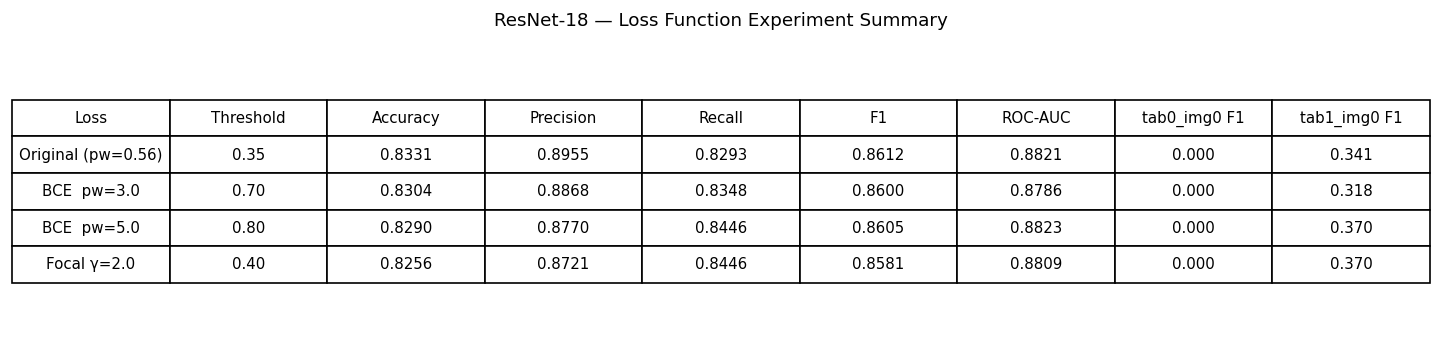

All results saved.


In [11]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")

def get_f1(sg, combo):
    r = sg[sg["combo_type"]==combo]
    return f"{r['f1'].values[0]:.3f}" if len(r)>0 else "N/A"

col_labels = ["Loss","Threshold","Accuracy","Precision","Recall",
              "F1","ROC-AUC","tab0_img0 F1","tab1_img0 F1"]
cell_data  = []
for r in results:
    m = r["metrics"]
    cell_data.append([
        r["label"],
        f"{r['threshold']:.2f}",
        f"{m['accuracy']:.4f}", f"{m['precision']:.4f}",
        f"{m['recall']:.4f}",   f"{m['f1']:.4f}",
        f"{m['roc_auc']:.4f}",
        get_f1(r["sg"], "tab0_img0"),
        get_f1(r["sg"], "tab1_img0"),
    ])

tbl = ax.table(cellText=cell_data,
               colLabels=col_labels,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.1, 1.8)
ax.set_title("ResNet-18 — Loss Function Experiment Summary", fontsize=11, pad=15)
fig.tight_layout()
fig.savefig(RESULTS_PW3.parent / "mm_image_resnet18_loss_exp_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("All results saved.")